# ClinicalTrials.gov — EDA
Preprocessing and exploratory analysis on the raw collected data before joining with OpenFDA.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("clinical_trials_raw.csv")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (114022, 29)


,nct_id,brief_title,overall_status,start_date,primary_completion_date,completion_date,is_fda_regulated_drug,is_fda_regulated_device,has_dmc,study_type,...,num_collaborators,intervention_types,drug_names,is_drug_trial,conditions,minimum_age,maximum_age,sex,healthy_volunteers,num_sites
0,NCT00355524,"A Phase 2 Study to Evaluate Pharmacokinetics, ...",COMPLETED,2006-06,2007-08,2011-03,NaN,NaN,True,INTERVENTIONAL,...,0,DRUG,TMC114|Ritonavir,True,HIV-1|HIV Infections,6 Years,17 Years,ALL,False,22
1,NCT01196624,Repetitive Transcranial Magnetic Stimulation W...,COMPLETED,2008-11,2013-02,2013-02,NaN,NaN,False,INTERVENTIONAL,...,0,DEVICE,NaN,False,Flashbacks|Posttraumatic Stress Disorder,18 Years,65 Years,ALL,False,1
2,NCT00147524,Non-Comparative Study To Evaluate Changes In F...,COMPLETED,2003-10,NaN,2005-05,NaN,NaN,NaN,INTERVENTIONAL,...,0,DRUG|PROCEDURE,quinapril,True,Menopause|Hypertension,18 Years,75 Years,FEMALE,False,5


## Preprocessing & Wrangling

In [ ]:
# Parse dates — some are YYYY-MM, some are YYYY-MM-DD; coerce handles both
for col in ["start_date", "primary_completion_date", "completion_date"]:
    df[col] = pd.to_datetime(df[col], format="mixed", yearfirst=True, errors="coerce")

# Trial duration in days: start → primary completion
df["duration_days"] = (df["primary_completion_date"] - df["start_date"]).dt.days

# Start year, useful for temporal analysis and train/test split
df["start_year"] = df["start_date"].dt.year

# Parse age strings like "18 Years", "6 Months" -> float years
def parse_age(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if "Month" in val:
        return float(val.split()[0]) / 12
    if "Week" in val:
        return float(val.split()[0]) / 52
    if "Year" in val or val.replace(".", "").isdigit():
        return float(val.split()[0])
    return np.nan

df["min_age_years"] = df["minimum_age"].apply(parse_age)
df["max_age_years"] = df["maximum_age"].apply(parse_age)
df["age_range_years"] = df["max_age_years"] - df["min_age_years"]

# Simplify phases: collapse multi-phase strings to the highest phase number
def simplify_phase(val):
    if pd.isna(val):
        return "Unknown"
    if "PHASE4" in val:
        return "Phase 4"
    if "PHASE3" in val:
        return "Phase 3"
    if "PHASE2" in val:
        return "Phase 2"
    if "PHASE1" in val:
        return "Phase 1"
    if "NA" in val or "NOT_APPLICABLE" in val:
        return "N/A"
    return "Other"

df["phase_simple"] = df["phases"].apply(simplify_phase)

# Boolean columns stored as strings — convert to proper bool
for col in ["is_fda_regulated_drug", "is_fda_regulated_device", "has_dmc", "is_drug_trial"]:
    df[col] = df[col].map({"True": True, "False": False, True: True, False: False})

print("Preprocessing done.")
print(f"duration_days: {df['duration_days'].notna().sum():,} non-null")
print(f"start_year range: {df['start_year'].min():.0f} – {df['start_year'].max():.0f}")
df[["duration_days", "start_year", "min_age_years", "max_age_years", "phase_simple"]].describe()

Preprocessing done.
duration_days: 109,948 non-null
start_year range: 1900 – 2050


,duration_days,start_year,min_age_years,max_age_years
count,109948.000000,114022.000000,106419.000000,57365.000000
mean,831.191463,2014.449931,19.821537,59.218705
std,854.980844,6.401260,10.793088,26.098589
min,0.000000,1900.000000,0.000000,0.019231
25%,274.000000,2010.000000,18.000000,45.000000
50%,607.000000,2015.000000,18.000000,65.000000
75%,1123.000000,2020.000000,18.000000,75.000000
max,35490.000000,2050.000000,95.000000,200.000000


## EDA

### 1. Class Distribution

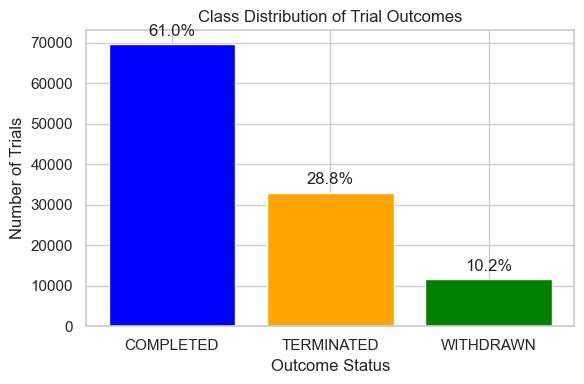

overall_status
COMPLETED     69541
TERMINATED    32878
WITHDRAWN     11603


In [18]:
counts = df["overall_status"].value_counts()
pcts = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['blue', 'orange', 'green'])
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in pcts], padding=4)
ax.set_title("Class Distribution of Trial Outcomes")
ax.set_ylabel("Number of Trials")
ax.set_xlabel("Outcome Status")
plt.tight_layout()
plt.show()

print(counts.to_string())

### 2. Trial Duration by Outcome

Duration = days from start to primary completion

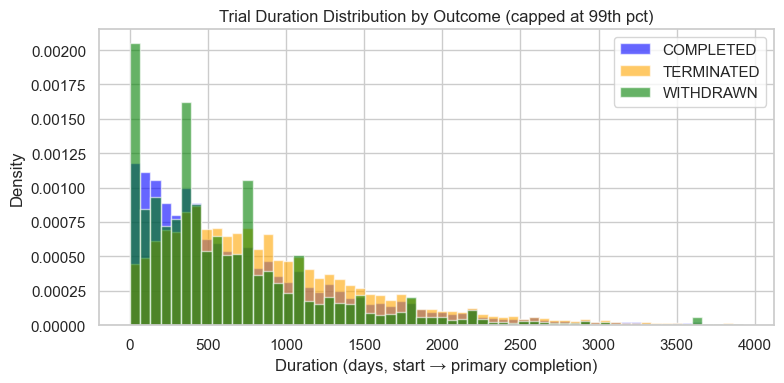

overall_status
COMPLETED     548.0
TERMINATED    749.0
WITHDRAWN     457.0
Name: duration_days, dtype: float64


In [19]:
# Cap at 99th percentile to suppress extreme outliers
cap = df["duration_days"].quantile(0.99)
plot_df = df[df["duration_days"].between(0, cap)].copy()

fig, ax = plt.subplots(figsize=(8, 4))
for status, color in zip(["COMPLETED", "TERMINATED", "WITHDRAWN"],
                         ["blue", "orange", "green"]):
    subset = plot_df[plot_df["overall_status"] == status]["duration_days"]
    ax.hist(subset, bins=60, alpha=0.6, label=status, color=color, density=True)

ax.set_title("Trial Duration Distribution by Outcome (capped at 99th pct)")
ax.set_xlabel("Duration (days, start → primary completion)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Median durations
print(df.groupby("overall_status")["duration_days"].median().round(0))

### 3. Outcome Rate by Sponsor Class

Industry vs. NIH vs. other: does who funds the trial predict whether it completes?

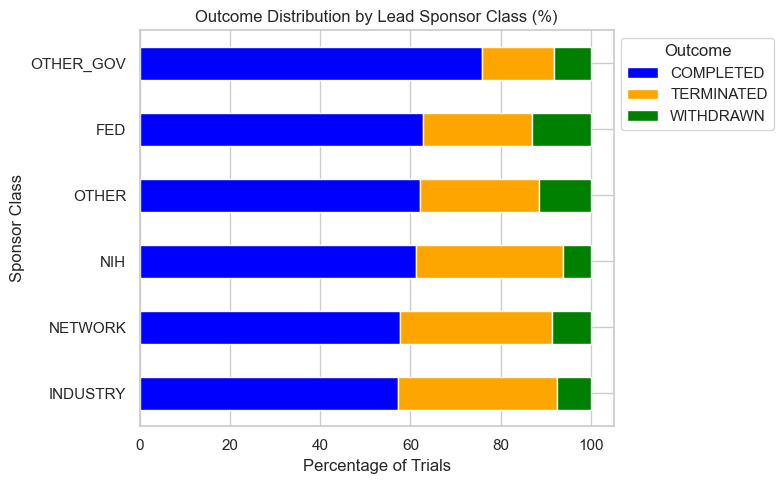

In [ ]:
# Normalize outcome counts within each sponsor class -> proportions
sponsor_outcome = (
    df.groupby(["lead_sponsor_class", "overall_status"])
    .size()
    .unstack(fill_value=0)
)
sponsor_outcome_pct = sponsor_outcome.div(sponsor_outcome.sum(axis=1), axis=0) * 100

# Keep only sponsor classes with enough trials to be meaningful
min_count = 200
valid = sponsor_outcome[sponsor_outcome.sum(axis=1) >= min_count].index
sponsor_outcome_pct = sponsor_outcome_pct.loc[valid].sort_values("COMPLETED")

ax = sponsor_outcome_pct.plot(
    kind="barh", stacked=True, figsize=(8, 5),
    color=["blue", "orange", "green"]
)
ax.set_title("Outcome Distribution by Lead Sponsor Class (%)")
ax.set_xlabel("Percentage of Trials")
ax.set_ylabel("Sponsor Class")
ax.legend(title="Outcome", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### 4. Enrollment Count by Outcome and Phase

Log-scaled enrollment count: larger trials may be better resourced and more likely to complete.

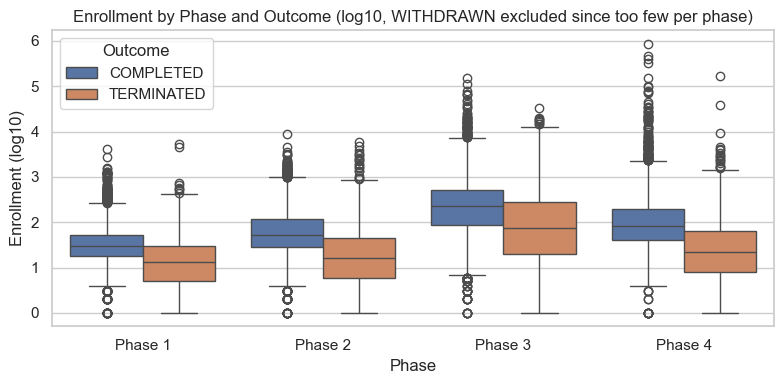

In [22]:
# WITHDRAWN has very few rows per phase (<35), so only plot COMPLETED and TERMINATED
plot_df = df[
    df["enrollment_count"].notna() &
    (df["enrollment_count"] > 0) &
    (df["phase_simple"].isin(["Phase 1", "Phase 2", "Phase 3", "Phase 4"])) &
    (df["overall_status"].isin(["COMPLETED", "TERMINATED"]))
].copy()
plot_df["log_enrollment"] = np.log10(plot_df["enrollment_count"])

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=plot_df,
    x="phase_simple", y="log_enrollment", hue="overall_status",
    order=["Phase 1", "Phase 2", "Phase 3", "Phase 4"],
    ax=ax
)
ax.set_title("Enrollment by Phase and Outcome (log10, WITHDRAWN excluded since too few per phase)")
ax.set_xlabel("Phase")
ax.set_ylabel("Enrollment (log10)")
ax.legend(title="Outcome")
plt.tight_layout()
plt.show()

### 5. Trial Start Volume and Termination Rate Over Time

How many trials started each year, and did the share that terminated or withdrew change over time?

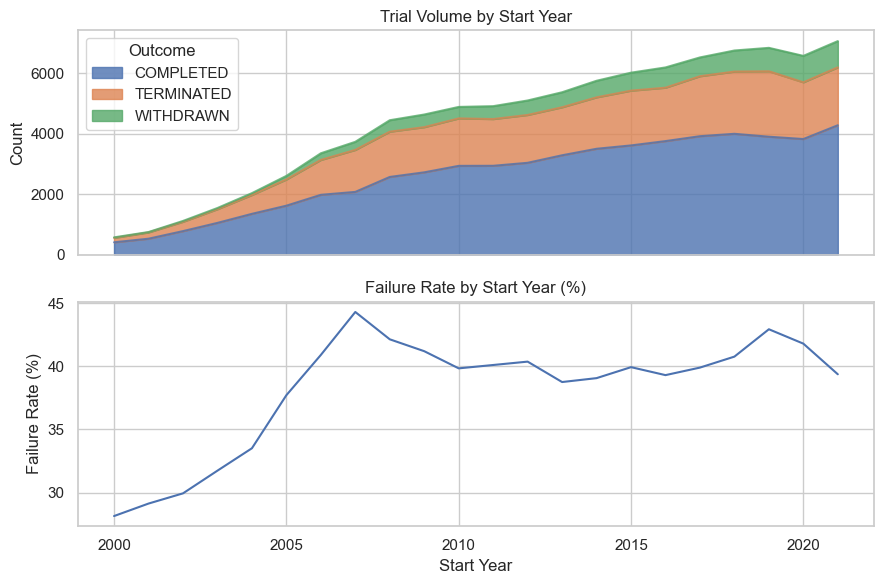

In [23]:
yearly = (
    df[df["start_year"].between(2000, 2021)]  # 2022+ trials may not have resolved yet
    .groupby(["start_year", "overall_status"])
    .size()
    .unstack(fill_value=0)
)
yearly["failure_rate"] = (
    (yearly.get("TERMINATED", 0) + yearly.get("WITHDRAWN", 0)) / yearly.sum(axis=1) * 100
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

yearly[["COMPLETED", "TERMINATED", "WITHDRAWN"]].plot.area(ax=ax1, alpha=0.8)
ax1.set_title("Trial Volume by Start Year")
ax1.set_ylabel("Count")
ax1.legend(title="Outcome")

ax2.plot(yearly.index, yearly["failure_rate"])
ax2.set_title("Failure Rate by Start Year (%)")
ax2.set_xlabel("Start Year")
ax2.set_ylabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

### 6. Missing Value Heatmap

Which columns have the most missing data, and does missingness vary by outcome class?

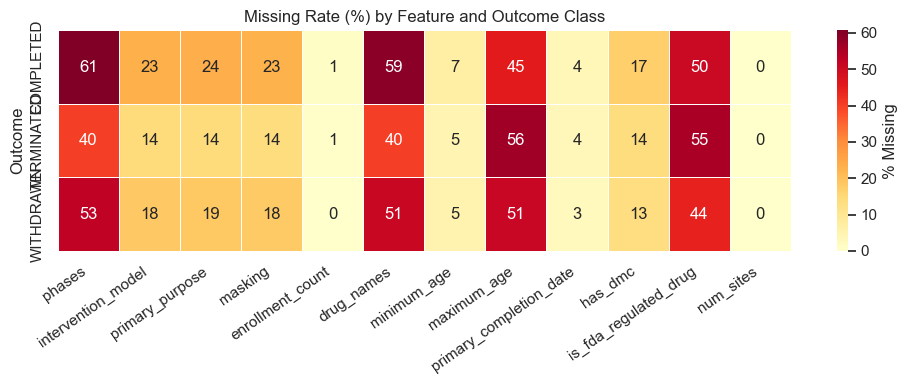

In [24]:
# Missing rate per column, split by outcome class
feature_cols = [
    "phases", "intervention_model", "primary_purpose", "masking",
    "enrollment_count", "drug_names", "minimum_age", "maximum_age",
    "primary_completion_date", "has_dmc", "is_fda_regulated_drug", "num_sites"
]

missing_by_class = (
    df.groupby("overall_status")[feature_cols]
    .apply(lambda g: g.isnull().mean() * 100)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    missing_by_class,
    annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "% Missing"}
)
ax.set_title("Missing Rate (%) by Feature and Outcome Class")
ax.set_xlabel("")
ax.set_ylabel("Outcome")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()